In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import json

In [85]:
#csv_filename
fcompany_revenue = '../../dataset/csv/Company Revenue Segment for 10 top industires in transportation sector.csv'
fdaily_transaction = '../../dataset/csv/daily_transaction_for_10_top_industy_in_transportation.csv'
fidx_market = '../../dataset/csv/IDX_market_summary.csv'
fcompany_name = '../../dataset/csv/Top 10 transportation companies by market cap.csv'
fshareholder_composition = '../../dataset/csv/top10-transportation-by-market-cap-shareholder-composition.csv'
filename_list_csv = [fcompany_revenue, fdaily_transaction, fidx_market, fcompany_name, fshareholder_composition]

In [86]:
#json_filename
fcorporate_action = '../../dataset/json/top10-transportation-by-market-cap-corporate-action.json'
fcompany_report = '../../dataset/json/top10-transportation-by-marketcap-company_report.json'

filename_list_json = [fcorporate_action, fcompany_report]

In [87]:
#functions for turning json dataframe to dataframe
def json_dataframe_to_dataframe(filename):
    with open(filename) as f:
        dataframe_json = json.load(f)

    dataframe_json = {key: pd.DataFrame(records) for key, records in dataframe_json.items()}
    return dataframe_json

In [88]:
#loading the dataframes
list_dataframe_csv = []
list_dataframe_json = []

for i in range(len(filename_list_csv)):
    if i == 0:
        list_dataframe_csv.append(pd.read_csv(filename_list_csv[i]).rename(columns=lambda x : f'{x}_company_revenue' if x != 'symbol' else x))
    elif i == 1:
        list_dataframe_csv.append(pd.read_csv(filename_list_csv[i]).rename(columns=lambda x : f'{x}_daily_transaction' if x != 'symbol' else x))
    elif i == 2:
        list_dataframe_csv.append(pd.read_csv(filename_list_csv[i]).rename(columns=lambda x : f'{x}_idx_market' if x != 'symbol' else x))
    elif i == 3:
        list_dataframe_csv.append(pd.read_csv(filename_list_csv[i]).rename(columns=lambda x : f'{x}_company_name' if x != 'symbol' else x))
    else:
        list_dataframe_csv.append(pd.read_csv(filename_list_csv[i]).rename(columns=lambda x : f'{x}_shareholder_composition' if x != 'symbol' else x))

for i in range(len(filename_list_json)):
    json_dataframe = json_dataframe_to_dataframe(filename_list_json[i])
    list_dataframe_json.append(json_dataframe)

In [89]:
# for i in range(len(list_dataframe_json)):
#     for key,df in list_dataframe_json[i].items():
#         print(df.info())

In [90]:
#mengubah menjadi datetime untuk dataframe json
for i in range(len(list_dataframe_json)):
    for key,df in list_dataframe_json[i].items():
        for column in df.columns:
            if 'date' in column:
                list_dataframe_json[i][key][column] = pd.to_datetime(list_dataframe_json[i][key][column], format=r'%Y-%m-%d', errors='coerce')

In [91]:
#mengubah menjadi datetime untuk dataframe json
for i in range(len(list_dataframe_csv)):
    for column in list_dataframe_csv[i].columns.to_list():
        if 'date' in column:
            list_dataframe_csv[i][column] = pd.to_datetime(list_dataframe_csv[i][column], format=r'%Y-%m-%d', errors='coerce')
            break

agm : Annual General Meeting (Rapat Umum Pemegang Shaam)


`symbol `(Kode Saham): Menunjukkan kode unik (ticker) perusahaan yang terdaftar di bursa efek. Akhiran .JK menandakan bahwa saham tersebut diperdagangkan di Bursa Efek Indonesia (Jakarta). Contoh: TMAS.JK dan ELPI.JK.

`ex_date` (Tanggal Ex-Dividen): Singkatan dari Ex-Dividend Date. Ini adalah hari pertama saham diperdagangkan tanpa hak untuk menerima dividen berikutnya. Artinya, jika Anda membeli saham pada atau setelah tanggal ini, Anda tidak berhak mendapatkan dividen tersebut. Anda harus membeli saham sebelum tanggal ini (saat Cum Date) untuk mendapatkan dividen.

`payment_date` (Tanggal Pembayaran): Tanggal di mana dana dividen secara resmi ditransfer atau dibayarkan ke Rekening Dana Nasabah (RDN) milik para pemegang saham yang berhak.

`dividend_yield` (Imbal Hasil Dividen): Rasio keuangan yang menunjukkan persentase keuntungan yang diberikan perusahaan melalui dividen, diukur dari harga sahamnya. Angka ini didapat dari membagi total dividen per saham dengan harga saham saat itu. (Catatan: NaN pada baris pertama berarti data harganya tidak tersedia untuk dihitung saat itu).

`dividend_amount` (Nominal Dividen): Jumlah uang tunai (dalam Rupiah, karena ini saham bursa Jakarta) yang dibayarkan oleh perusahaan untuk setiap satu lembar saham yang dimiliki oleh investor. Misalnya, 8.000 berarti pemegang saham mendapat Rp8 per lembar saham.

Melihat banyak data dalam dataframe

In [92]:
len(list_dataframe_csv)

5

In [93]:
data0 = list_dataframe_csv[0]
data1 = list_dataframe_csv[1]
data2 = list_dataframe_csv[2]
data3 = list_dataframe_csv[3]
data4 = list_dataframe_csv[4]


# DATA PREPROCESSING

## Memproses data 0

In [94]:
data0

,company_name_company_revenue,value_company_revenue,source_company_revenue,target_company_revenue,financial_year_company_revenue
0,TMAS.JK,4150671000000,Shipping service,Total Revenue,2023
1,TMAS.JK,155013000000,Stevedoring service,Total Revenue,2023
2,TMAS.JK,3191753000000,Total Revenue,Cost of Revenue,2023
3,TMAS.JK,1113931000000,Total Revenue,Gross Profit,2023
4,TMAS.JK,929485000000,Gross Profit,Operating Income,2023
...,...,...,...,...,...
87,BIRD.JK,1629499000000,Total Revenue,Gross Profit,2024
88,BIRD.JK,634104000000,Gross Profit,Operating Income,2024
89,BIRD.JK,995395000000,Gross Profit,Operating Expense,2024
90,BIRD.JK,33825000000,Operating Expense,Selling,2024


In [95]:
data0.describe()

,value_company_revenue,financial_year_company_revenue
count,9.200000e+01,92.00000
mean,9.338136e+11,2023.50000
std,1.744658e+12,0.50274
min,5.955000e+07,2023.00000
25%,3.021324e+09,2023.00000
50%,1.772492e+11,2023.50000
75%,9.375062e+11,2024.00000
max,8.285540e+12,2024.00000


In [96]:
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   company_name_company_revenue    92 non-null     object
 1   value_company_revenue           92 non-null     int64 
 2   source_company_revenue          92 non-null     object
 3   target_company_revenue          92 non-null     object
 4   financial_year_company_revenue  92 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 3.7+ KB


Melihat pergerakan company revenue

In [97]:
import numpy as np
np.unique(data0['company_name_company_revenue'])

array(['BIRD.JK', 'HATM.JK', 'SMDR.JK', 'TMAS.JK'], dtype=object)

## Memproses data1

In [99]:
data1

,symbol,date_daily_transaction,close_daily_transaction,open_daily_transaction,high_daily_transaction,low_daily_transaction,volume_daily_transaction,market_cap_daily_transaction
0,GIAA.JK,2026-08-12,74,75,75,70,7.644107e+08,3.012479e+13
1,GIAA.JK,2026-08-13,72,75,76,71,3.559420e+08,2.931060e+13
2,GIAA.JK,2026-08-14,76,72,78,68,1.248689e+09,3.093897e+13
3,GIAA.JK,2026-08-18,75,77,80,74,5.559419e+08,3.053188e+13
4,GIAA.JK,2026-08-19,73,75,76,72,2.173927e+08,2.971769e+13
...,...,...,...,...,...,...,...,...
185,BLOG.JK,2026-09-03,380,380,380,378,2.824000e+05,1.284205e+12
186,BLOG.JK,2026-09-04,382,380,384,378,1.098100e+06,1.290964e+12
187,BLOG.JK,2026-09-07,378,380,382,376,8.964000e+05,1.277446e+12
188,BLOG.JK,2026-09-08,378,378,380,376,3.848000e+05,1.277446e+12


In [100]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   symbol                        190 non-null    object        
 1   date_daily_transaction        190 non-null    datetime64[ns]
 2   close_daily_transaction       190 non-null    int64         
 3   open_daily_transaction        190 non-null    int64         
 4   high_daily_transaction        190 non-null    int64         
 5   low_daily_transaction         190 non-null    int64         
 6   volume_daily_transaction      190 non-null    float64       
 7   market_cap_daily_transaction  190 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 12.0+ KB


In [101]:
data1.describe()

,date_daily_transaction,close_daily_transaction,open_daily_transaction,high_daily_transaction,low_daily_transaction,volume_daily_transaction,market_cap_daily_transaction
count,190,190.000000,190.000000,190.000000,190.000000,1.900000e+02,1.900000e+02
mean,2026-08-26 12:37:53.684210432,531.205263,530.300000,540.800000,521.121053,3.729504e+07,6.858893e+12
min,2026-08-12 00:00:00,63.000000,62.000000,66.000000,61.000000,8.460000e+04,1.257169e+12
25%,2026-08-19 00:00:00,170.250000,172.250000,173.250000,166.500000,1.168500e+06,2.348486e+12
50%,2026-08-27 00:00:00,470.500000,470.500000,499.000000,440.000000,7.370600e+06,5.131569e+12
75%,2026-09-03 00:00:00,655.000000,655.000000,675.000000,648.750000,1.690100e+07,6.381361e+12
max,2026-09-09 00:00:00,1660.000000,1670.000000,1670.000000,1650.000000,1.248689e+09,3.093897e+13
std,NaN,429.729846,430.305416,433.115015,426.572610,1.231992e+08,7.418391e+12


### Daily Transaction per Transaction

In [102]:
daily_transaction_per_transaction = ['close_daily_transaction', 'open_daily_transaction', 'high_daily_transaction','low_daily_transaction' ]
volume_vs_market_cap = ['volume_daily_transaction', 'market_cap_daily_transaction']

In [103]:
ticker = data1['symbol'].unique()

In [104]:
ticker

array(['GIAA.JK', 'TMAS.JK', 'ELPI.JK', 'WBSA.JK', 'SMDR.JK', 'HATM.JK',
       'BIRD.JK', 'ASSA.JK', 'IMJS.JK', 'BLOG.JK'], dtype=object)

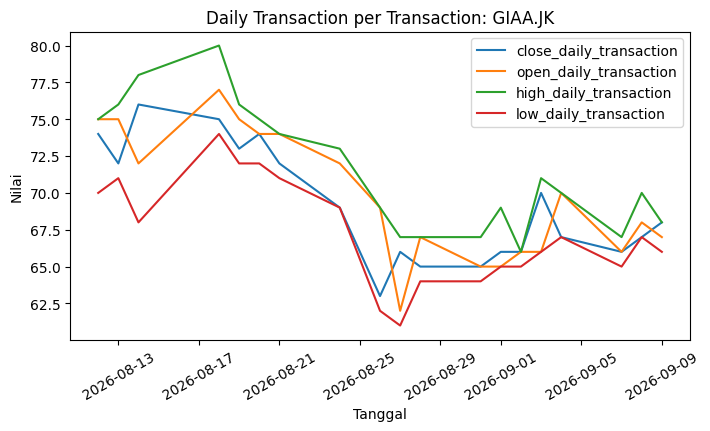

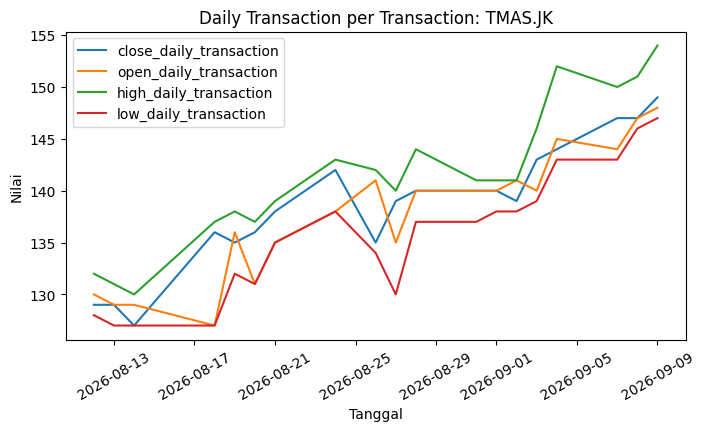

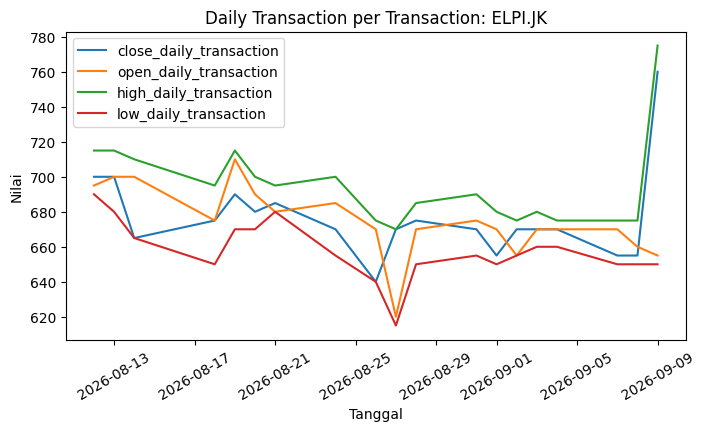

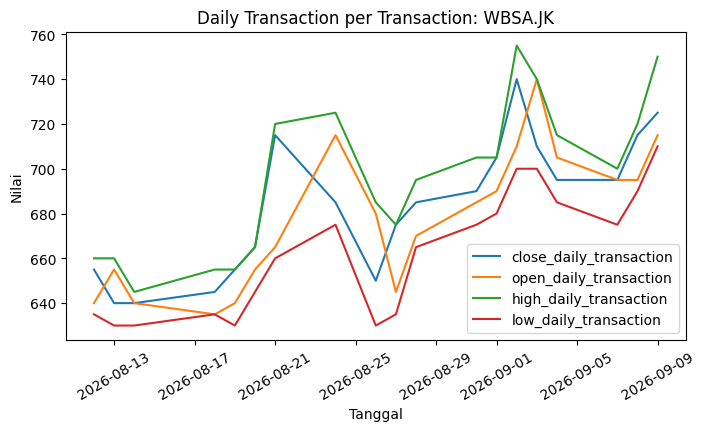

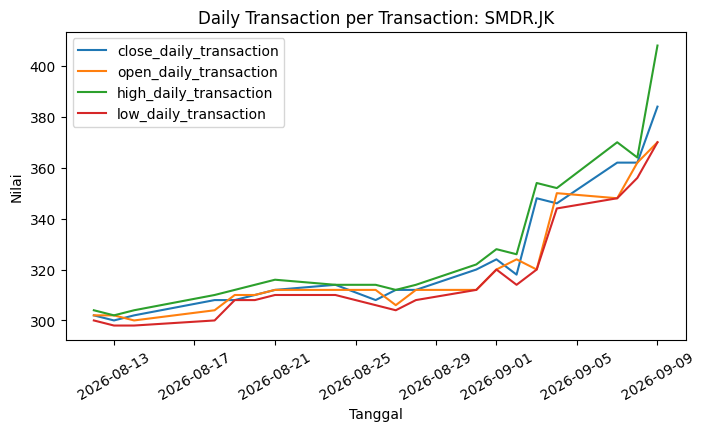

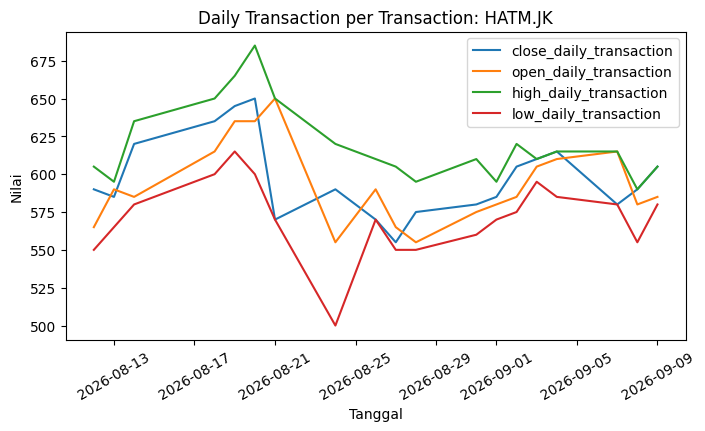

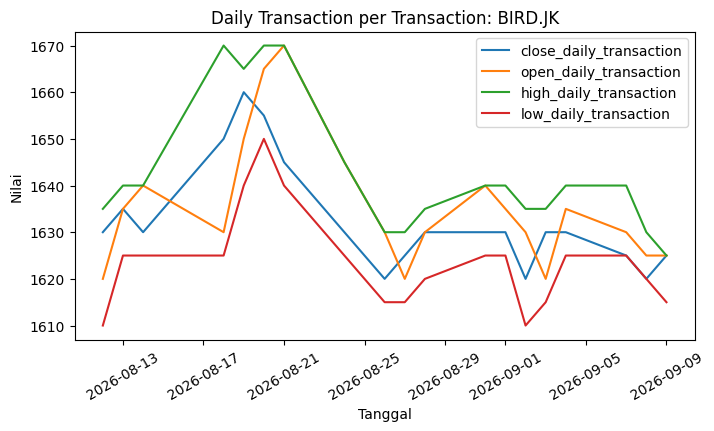

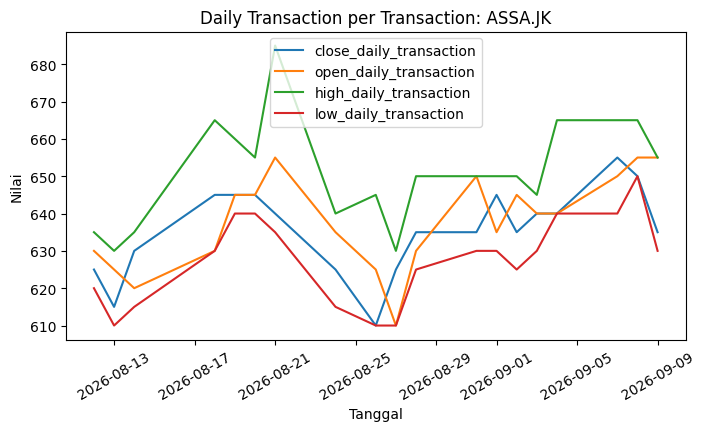

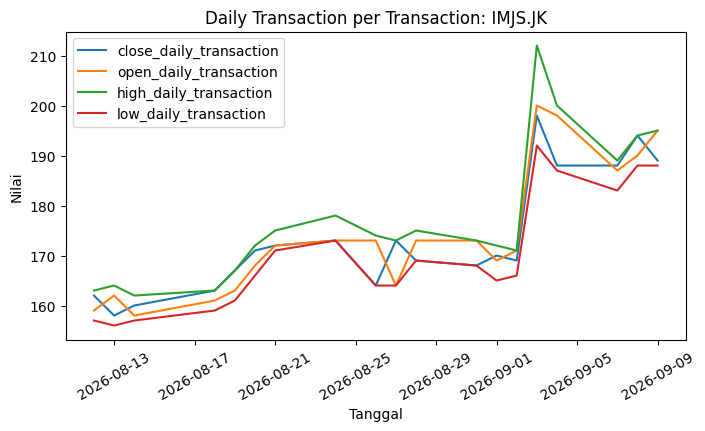

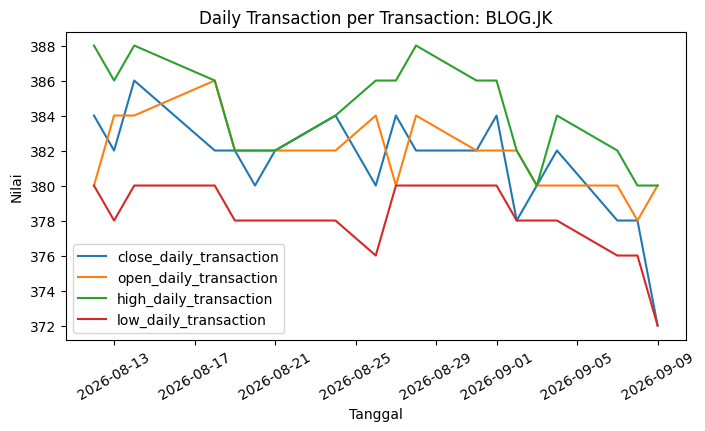

In [105]:
import seaborn as sns

for i in ticker:
    plt.figure(figsize=(8,4))
    df_temp = data1[data1['symbol']==i]
    for j in daily_transaction_per_transaction:
        sns.lineplot(df_temp, x ='date_daily_transaction', y = j, label = j,)
    plt.legend()
    plt.xlabel("Tanggal")
    plt.ylabel('Nilai')
    plt.xticks(rotation = 30)
    plt.title(f'Daily Transaction per Transaction: {i}')
    plt.show()


### Volume for daily Transaction

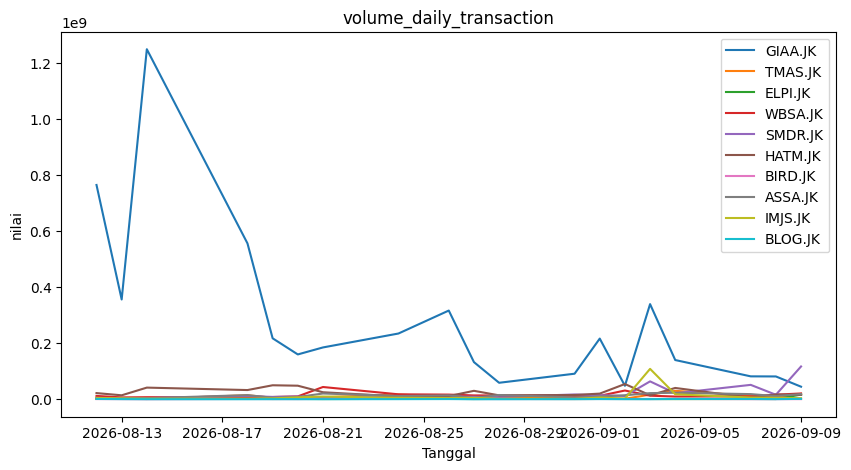

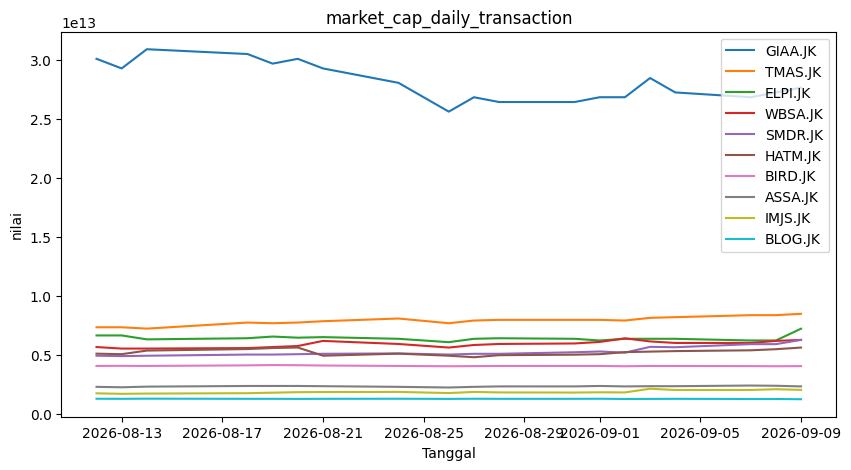

In [106]:
for i in volume_vs_market_cap: 
    plt.figure(figsize=(10,5))
    for j in ticker: 
        df_temp = data1[data1['symbol']==j]
        sns.lineplot(df_temp, x='date_daily_transaction', y = i,label = j)
    plt.xlabel('Tanggal')
    plt.ylabel('nilai')
    plt.legend()
    plt.title(i)
    plt.show()

## Memproses data 3

In [107]:
data3

,symbol,company_name_company_name
0,GIAA.JK,Garuda Indonesia (Persero) Tbk
1,TMAS.JK,PT Temas Tbk
2,ELPI.JK,PT Pelayaran Nasional Ekalya Purnamasari Tbk
3,WBSA.JK,PT BSA Logistics Indonesia Tbk
4,SMDR.JK,Samudera Indonesia Tbk
5,HATM.JK,PT Habco Trans Maritima Tbk
6,BIRD.JK,PT Blue Bird Tbk
7,ASSA.JK,Adi Sarana Armada Tbk
8,IMJS.JK,PT Indomobil Multi Jasa Tbk
9,BLOG.JK,PT Trimitra Trans Persada Tbk


## Memproses data4

In [108]:
data4.head(10)

,date_shareholder_composition,shares_number_shareholder_composition,insurance_l_shareholder_composition,corporate_l_shareholder_composition,pension_fund_l_shareholder_composition,financial_institutions_l_shareholder_composition,individual_l_shareholder_composition,mutual_fund_l_shareholder_composition,securities_companies_l_shareholder_composition,foundation_l_shareholder_composition,...,financial_institutions_f_shareholder_composition,individual_f_shareholder_composition,mutual_fund_f_shareholder_composition,securities_companies_f_shareholder_composition,foundation_f_shareholder_composition,other_f_shareholder_composition,total_f_shareholder_composition,numbers_of_shareholders_shareholder_composition,change_in_shareholders_shareholder_composition,symbol
0,2025-12-30,4.070917e+11,413892502.0,7.947530e+09,73830974.0,0.0,1.016295e+10,297804200.0,62332693.0,9720294.0,...,5.014816e+09,473172554.0,60327708.0,4.849386e+08,0.0,9.839097e+08,1.294052e+10,75057.0,-587.0,GIAA.JK
1,2025-11-28,9.148078e+10,419358102.0,7.966755e+09,73830974.0,0.0,9.954456e+09,351364200.0,62332775.0,9785294.0,...,5.018061e+09,472997454.0,60327708.0,4.797943e+08,0.0,9.839097e+08,1.307070e+10,75644.0,-53.0,GIAA.JK
2,2025-10-31,9.148078e+10,410694902.0,8.050170e+09,73830974.0,0.0,9.727477e+09,315014200.0,63582599.0,10305294.0,...,5.011939e+09,472832554.0,60327708.0,4.854181e+08,0.0,9.839097e+08,1.324020e+10,75697.0,10433.0,GIAA.JK
3,2025-09-30,9.148078e+10,413141402.0,8.017252e+09,73830974.0,0.0,8.916912e+09,249090400.0,62332514.0,10305294.0,...,4.726747e+09,498966054.0,60327708.0,4.912041e+08,0.0,1.147165e+09,1.413172e+10,86130.0,NaN,GIAA.JK
4,2025-08-29,9.148078e+10,421444202.0,7.920372e+09,73830974.0,0.0,9.328561e+09,248590400.0,62332649.0,10270294.0,...,4.344496e+09,504334354.0,60327708.0,4.890006e+08,0.0,1.147165e+09,1.379442e+10,NaN,NaN,GIAA.JK
5,2025-07-31,9.148078e+10,413141402.0,7.883455e+09,73830974.0,0.0,9.350294e+09,246090400.0,62332262.0,10270294.0,...,4.116150e+09,500518354.0,60327708.0,4.982496e+08,0.0,1.147165e+09,1.382040e+10,NaN,NaN,GIAA.JK
6,2025-06-30,9.148078e+10,413141402.0,7.946671e+09,73830974.0,0.0,9.766402e+09,225090400.0,92932187.0,10270294.0,...,3.602692e+09,498009354.0,60327708.0,5.278677e+08,0.0,1.147165e+09,1.333347e+10,NaN,NaN,GIAA.JK
7,2025-05-28,9.148078e+10,413141402.0,7.987073e+09,73850974.0,0.0,9.903276e+09,186251900.0,187432187.0,9750294.0,...,3.398042e+09,482387554.0,60327708.0,4.926482e+08,0.0,1.147165e+09,1.308727e+10,NaN,NaN,GIAA.JK
8,2025-04-30,9.148078e+10,413141402.0,7.928733e+09,74240974.0,0.0,9.030243e+09,84178700.0,62332225.0,9750294.0,...,3.451612e+09,453729654.0,60327708.0,1.184998e+09,0.0,1.148111e+09,1.424542e+10,NaN,NaN,GIAA.JK
9,2025-03-27,9.148078e+10,413141402.0,7.921681e+09,74240974.0,0.0,8.596566e+09,169279700.0,82332184.0,9750294.0,...,3.452558e+09,454598754.0,60327708.0,4.618635e+08,0.0,1.148111e+09,1.458105e+10,NaN,NaN,GIAA.JK


In [109]:
missing_value_data = data4[data4.isnull().any(axis=1)]
ticker_missing = missing_value_data['symbol'].unique()

In [110]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 25 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   date_shareholder_composition                      179 non-null    datetime64[ns]
 1   shares_number_shareholder_composition             179 non-null    float64       
 2   insurance_l_shareholder_composition               179 non-null    float64       
 3   corporate_l_shareholder_composition               179 non-null    float64       
 4   pension_fund_l_shareholder_composition            179 non-null    float64       
 5   financial_institutions_l_shareholder_composition  179 non-null    float64       
 6   individual_l_shareholder_composition              179 non-null    float64       
 7   mutual_fund_l_shareholder_composition             179 non-null    float64       
 8   securities_companies_l_shareho

In [111]:
data4.describe()

,date_shareholder_composition,shares_number_shareholder_composition,insurance_l_shareholder_composition,corporate_l_shareholder_composition,pension_fund_l_shareholder_composition,financial_institutions_l_shareholder_composition,individual_l_shareholder_composition,mutual_fund_l_shareholder_composition,securities_companies_l_shareholder_composition,foundation_l_shareholder_composition,...,pension_fund_f_shareholder_composition,financial_institutions_f_shareholder_composition,individual_f_shareholder_composition,mutual_fund_f_shareholder_composition,securities_companies_f_shareholder_composition,foundation_f_shareholder_composition,other_f_shareholder_composition,total_f_shareholder_composition,numbers_of_shareholders_shareholder_composition,change_in_shareholders_shareholder_composition
count,179,1.790000e+02,1.790000e+02,1.790000e+02,1.790000e+02,179.0,1.790000e+02,1.790000e+02,1.790000e+02,1.790000e+02,...,1.790000e+02,1.790000e+02,1.790000e+02,1.790000e+02,1.790000e+02,179.0,1.790000e+02,1.790000e+02,103.000000,94.000000
mean,2025-11-27 05:37:52.625698304,3.834477e+10,1.960238e+08,7.542053e+09,3.664845e+07,0.0,2.610485e+09,8.004486e+07,1.540659e+07,1.939982e+06,...,9.528139e+06,5.586166e+08,7.130557e+07,5.039673e+07,8.120114e+07,0.0,1.409061e+08,1.705003e+09,28447.601942,-5808.574468
min,2025-01-31 00:00:00,2.502100e+09,0.000000e+00,1.440670e+07,0.000000e+00,0.0,1.999977e+08,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,7.280000e+04,1.021000e+05,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.283100e+06,1497.000000,-358350.000000
25%,2025-06-30 00:00:00,3.691138e+09,0.000000e+00,7.136536e+08,0.000000e+00,0.0,4.631473e+08,1.250000e+04,1.100000e+02,0.000000e+00,...,0.000000e+00,3.273752e+07,2.878000e+05,5.641000e+05,3.695500e+05,0.0,4.755870e+06,7.607944e+07,8765.000000,-472.000000
50%,2025-11-28 00:00:00,8.675000e+09,1.629910e+07,2.011213e+09,5.343000e+06,0.0,9.265493e+08,2.927000e+07,8.120170e+05,1.000000e+02,...,0.000000e+00,5.130246e+07,1.339900e+06,4.918160e+07,1.042315e+07,0.0,1.524300e+07,2.194122e+08,14058.000000,-122.500000
75%,2026-04-30 00:00:00,1.637560e+10,5.299065e+07,8.122091e+09,2.488030e+07,0.0,2.131113e+09,1.363369e+08,3.305292e+06,7.650000e+05,...,6.230900e+06,1.755435e+08,7.413465e+07,6.337540e+07,8.073395e+07,0.0,9.928863e+07,4.644053e+08,20918.000000,236.750000
max,2026-08-31 00:00:00,4.070917e+11,1.252760e+09,4.158242e+10,2.548477e+08,0.0,1.113077e+10,3.538882e+08,1.874322e+08,1.304120e+07,...,7.241442e+07,5.021535e+09,5.271580e+08,2.292338e+08,1.184998e+09,0.0,1.148111e+09,1.458105e+10,565585.000000,10433.000000
std,NaN,8.856549e+10,3.940938e+08,1.250043e+10,6.733742e+07,0.0,3.319394e+09,1.031232e+08,2.974659e+07,3.775202e+06,...,2.053016e+07,1.388667e+09,1.537037e+08,5.979254e+07,1.682935e+08,0.0,3.061569e+08,4.100633e+09,61628.140644,38860.675119


#### Handling Missing Values

In [112]:
missing_value = data4.isnull().sum()
missing_value[missing_value>0]

numbers_of_shareholders_shareholder_composition    76
change_in_shareholders_shareholder_composition     85
dtype: int64

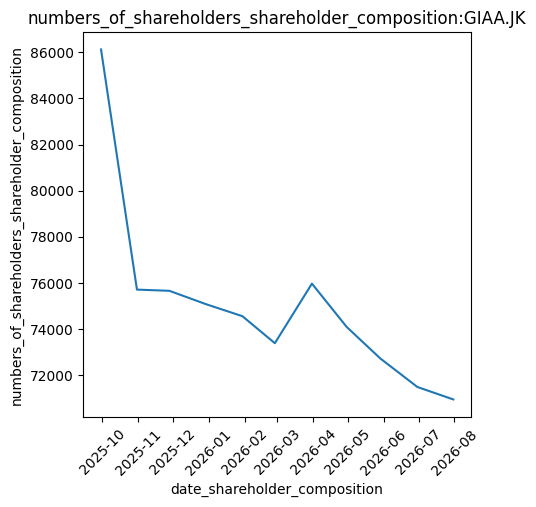

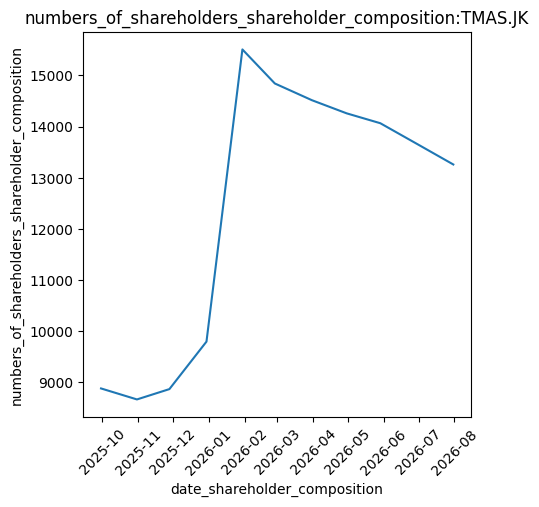

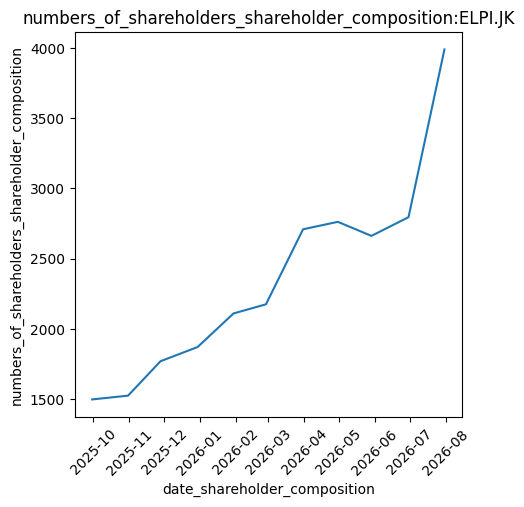

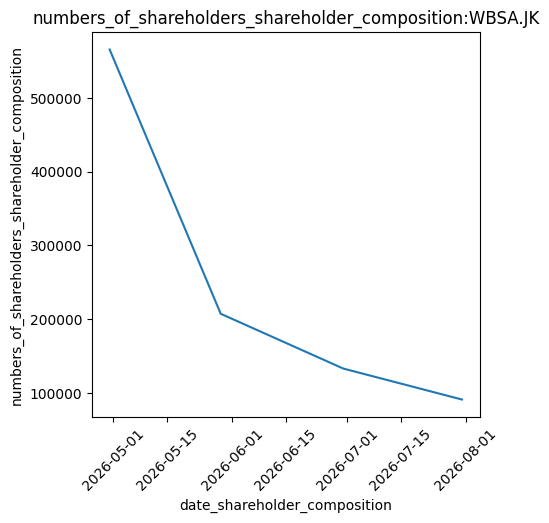

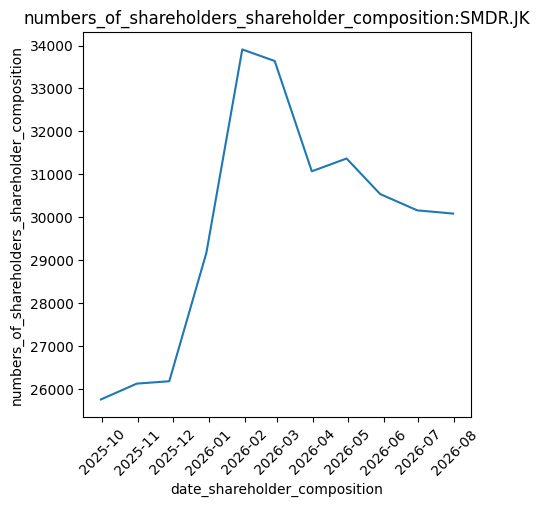

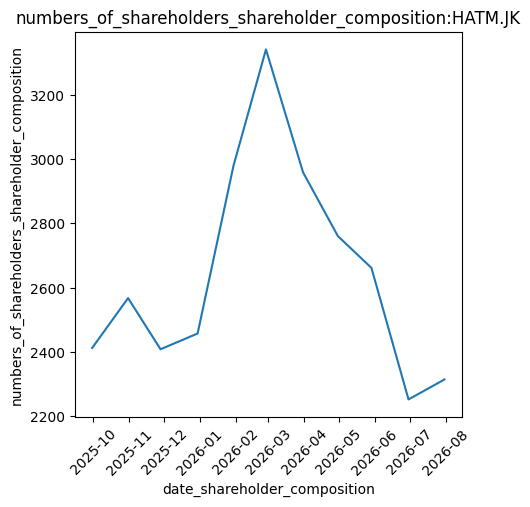

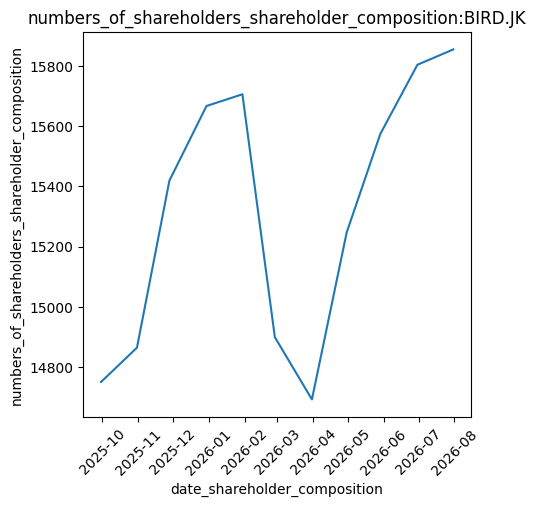

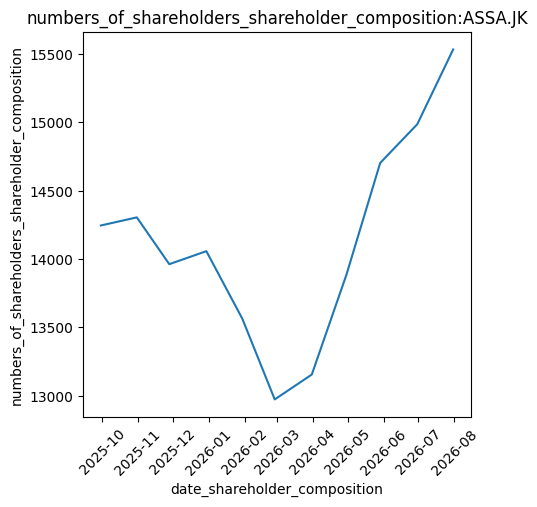

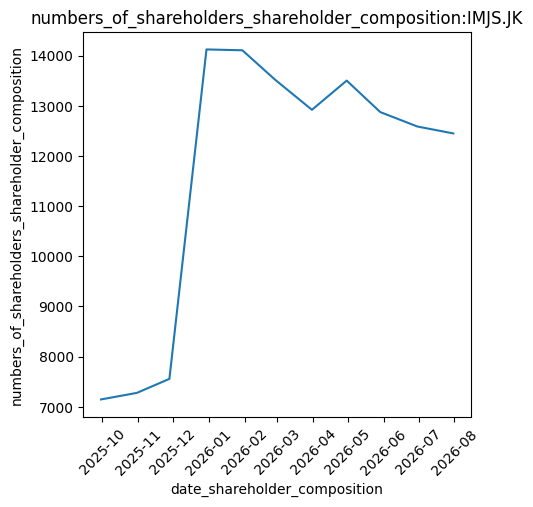

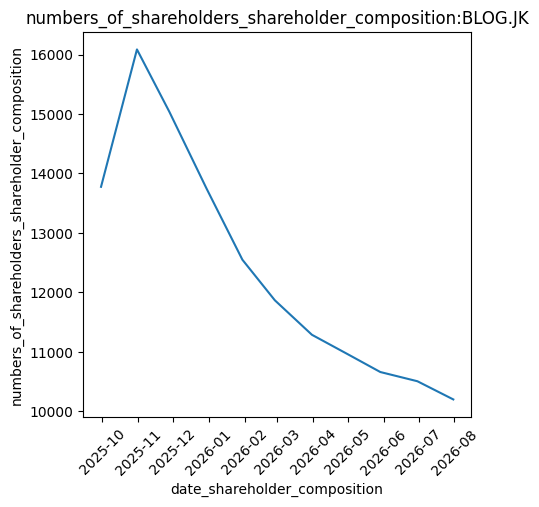

In [113]:
for i in ticker_missing:
    plt.figure(figsize=(5,5))
    data_temp = data4[data4['symbol']==i]
    sns.lineplot(data_temp,x = 'date_shareholder_composition', y = 'numbers_of_shareholders_shareholder_composition')
    plt.title(f'numbers_of_shareholders_shareholder_composition:{i}')
    plt.xticks(rotation=45)
    plt.show()

Setelah memperhatikan distribusi diatas, setiap data yang kosong akaan diisin oleh rata rata dari tiap tiap peruhaaan

In [118]:
kolom_target = ['change_in_shareholders_shareholder_composition', 'numbers_of_shareholders_shareholder_composition']

for j in kolom_target:
    # Mengisi NaN dengan rata-rata dari masing-masing grup 'symbol'
    data4[j] = data4[j].fillna(data4.groupby('symbol')[j].transform('mean'))
        

In [120]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 25 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   date_shareholder_composition                      179 non-null    datetime64[ns]
 1   shares_number_shareholder_composition             179 non-null    float64       
 2   insurance_l_shareholder_composition               179 non-null    float64       
 3   corporate_l_shareholder_composition               179 non-null    float64       
 4   pension_fund_l_shareholder_composition            179 non-null    float64       
 5   financial_institutions_l_shareholder_composition  179 non-null    float64       
 6   individual_l_shareholder_composition              179 non-null    float64       
 7   mutual_fund_l_shareholder_composition             179 non-null    float64       
 8   securities_companies_l_shareho

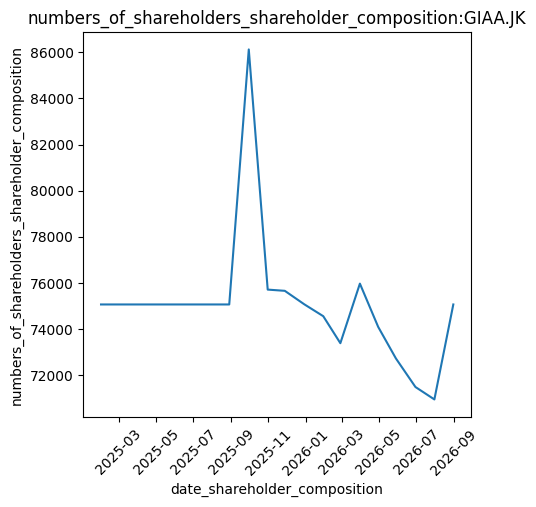

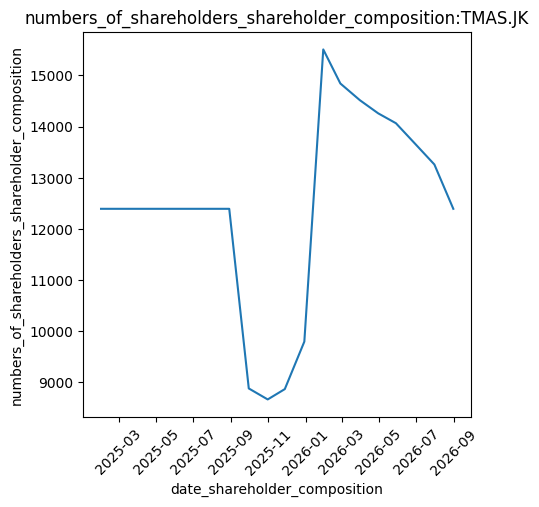

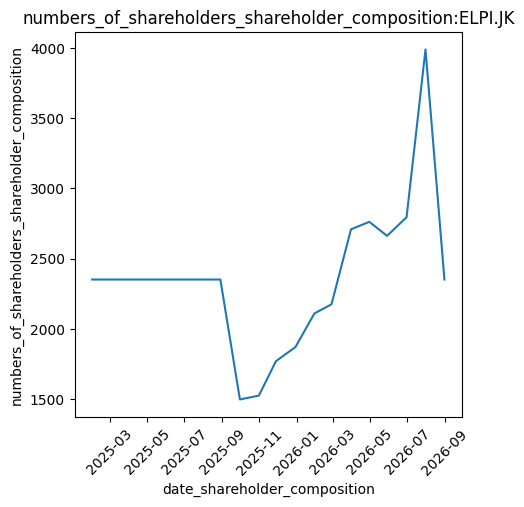

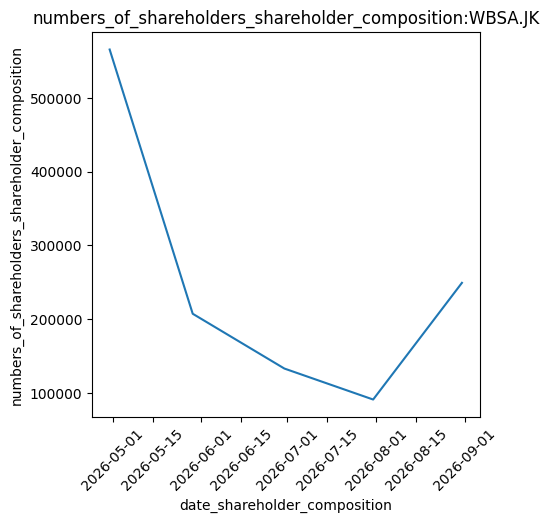

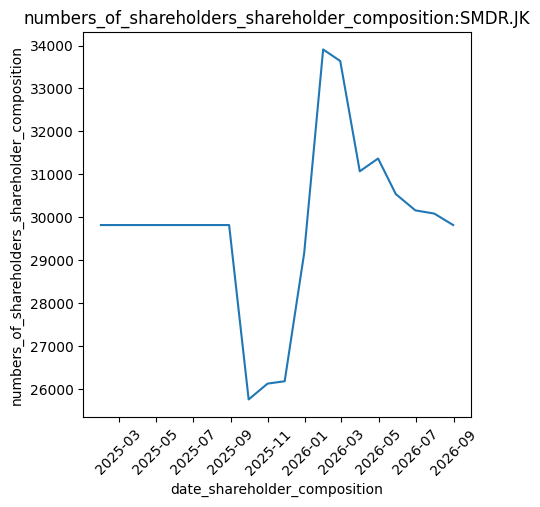

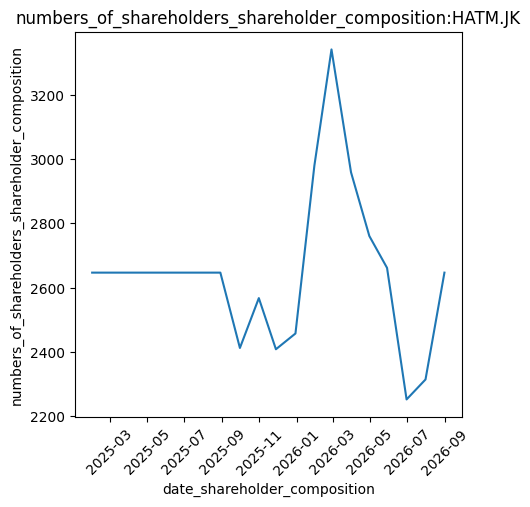

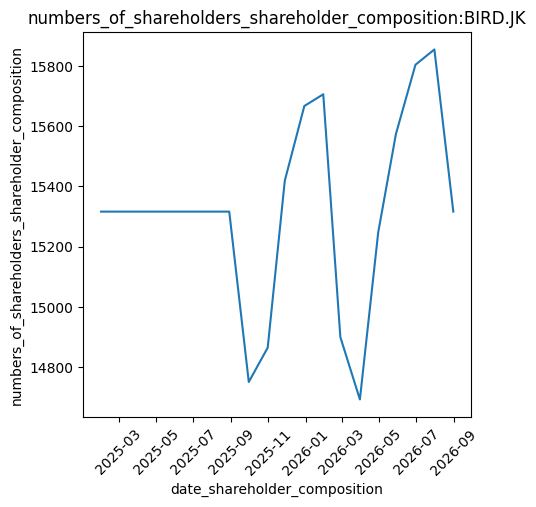

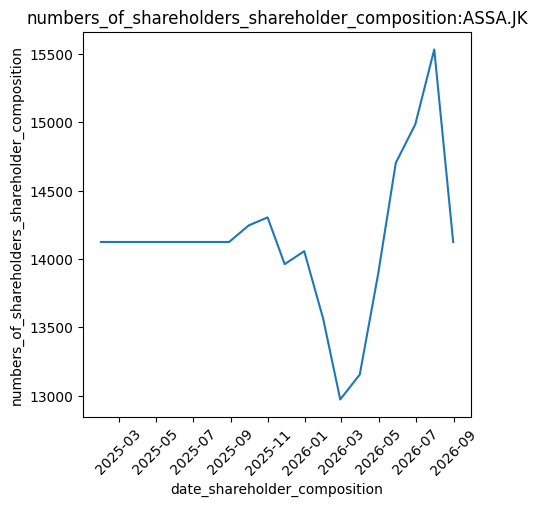

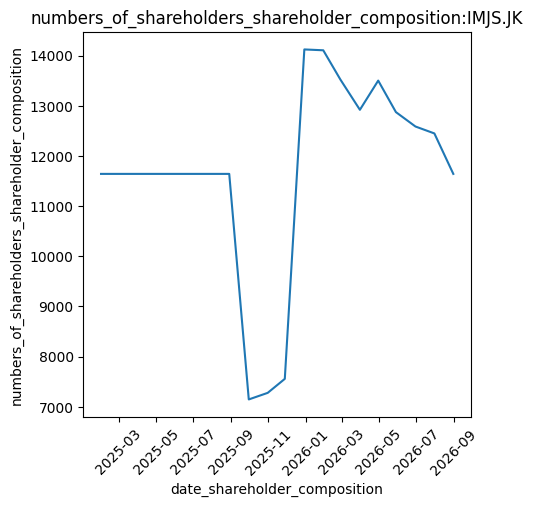

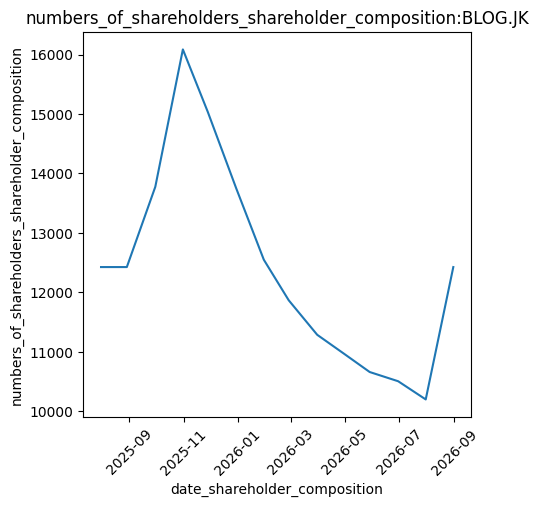

In [121]:
for i in ticker_missing:
    plt.figure(figsize=(5,5))
    data_temp = data4[data4['symbol']==i]
    sns.lineplot(data_temp,x = 'date_shareholder_composition', y = 'numbers_of_shareholders_shareholder_composition')
    plt.title(f'numbers_of_shareholders_shareholder_composition:{i}')
    plt.xticks(rotation=45)
    plt.show()

In [124]:
ticker_missing

array(['GIAA.JK', 'TMAS.JK', 'ELPI.JK', 'WBSA.JK', 'SMDR.JK', 'HATM.JK',
       'BIRD.JK', 'ASSA.JK', 'IMJS.JK', 'BLOG.JK'], dtype=object)

In [129]:
import yfinance as yf
import os

ticker = ticker_missing
for i in ticker:
    simbol = yf.Ticker(i)
    riwayat = simbol.history(period='5y')
    riwayat = pd.DataFrame(riwayat)
    os.makedirs('C:\MAIN DOC\Kuliah\SEMESTER 4\Dicoding\hackhaton\MikirSekali\dataset\csv\history', exist_ok=True)  # doctest: +SKIP
    riwayat.to_csv(f'Histori 5 taun terakhir {i}.csv')


<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
C:\Users\CHRISTIAN VAREL C\AppData\Local\Temp\ipykernel_10840\1337392322.py:9: SyntaxWarning: invalid escape sequence '\M'
  os.makedirs('C:\MAIN DOC\Kuliah\SEMESTER 4\Dicoding\hackhaton\MikirSekali\dataset\csv\history', exist_ok=True)  # doctest: +SKIP


In [130]:
hs_GIAA = pd.read_csv('..\..\dataset\csv\history\Histori 5 taun terakhir GIAA.JK.csv')
hs_GIAA.head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\CHRISTIAN VAREL C\AppData\Local\Temp\ipykernel_10840\3159439690.py:1: SyntaxWarning: invalid escape sequence '\.'
  hs_GIAA = pd.read_csv('..\..\dataset\csv\history\Histori 5 taun terakhir GIAA.JK.csv')


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-09-20 00:00:00+07:00,203.554138,203.554138,203.554138,203.554138,0,0.0,0.0
1,2021-09-21 00:00:00+07:00,203.554138,203.554138,203.554138,203.554138,0,0.0,0.0
2,2021-09-22 00:00:00+07:00,203.554138,203.554138,203.554138,203.554138,0,0.0,0.0
3,2021-09-23 00:00:00+07:00,203.554138,203.554138,203.554138,203.554138,0,0.0,0.0
4,2021-09-24 00:00:00+07:00,203.554138,203.554138,203.554138,203.554138,0,0.0,0.0


In [131]:
hs_GIAA.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')